# 04 - Exploratory Data Analysis (EDA)

## Overview
This notebook generates comprehensive visualizations:
- Consumption trends (hourly, daily, monthly)
- Zone comparisons
- Peak vs off-peak analysis
- Distributions and anomalies
- Top consumers and patterns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Imports successful")

Imports successful


In [2]:
# Setup paths and load data
PROJECT_ROOT = Path.cwd().parent if 'notebooks' in str(Path.cwd()) else Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
PLOTS_DIR = PROJECT_ROOT / 'outputs' / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

featured_file = DATA_PROCESSED / 'output_featured.csv'
df = pd.read_csv(featured_file)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

print(f"Loaded {len(df):,} records")
print(f"Columns: {len(df.columns)}")

Loaded 24,400 records
Columns: 33


## 1. Hourly Consumption Trend

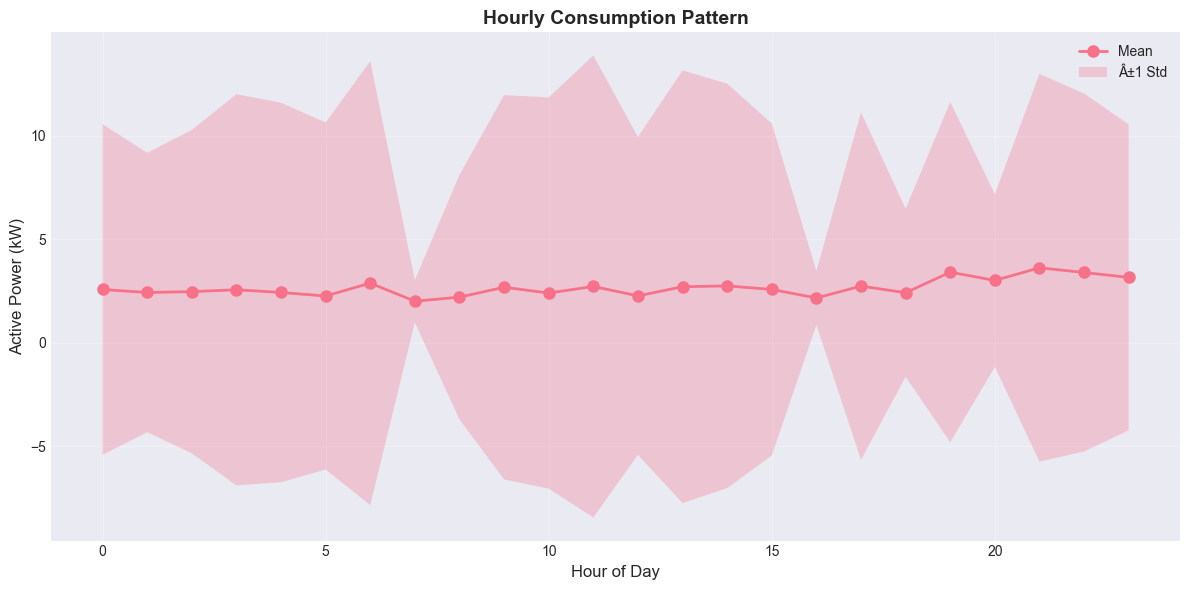

[CHECK]“ Hourly consumption trend saved


In [3]:
# Hourly consumption pattern
hourly_avg = df.groupby('hour')['Active_Power_kW'].agg(['mean', 'std']).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(hourly_avg['hour'], hourly_avg['mean'], marker='o', linewidth=2, markersize=8, label='Mean')
ax.fill_between(hourly_avg['hour'], 
                hourly_avg['mean'] - hourly_avg['std'],
                hourly_avg['mean'] + hourly_avg['std'],
                alpha=0.3, label='Â±1 Std')
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Active Power (kW)', fontsize=12)
ax.set_title('Hourly Consumption Pattern', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / '01_hourly_consumption.png', dpi=300)
plt.show()

print("[CHECK]“ Hourly consumption trend saved")

## 2. Daily Consumption Trend

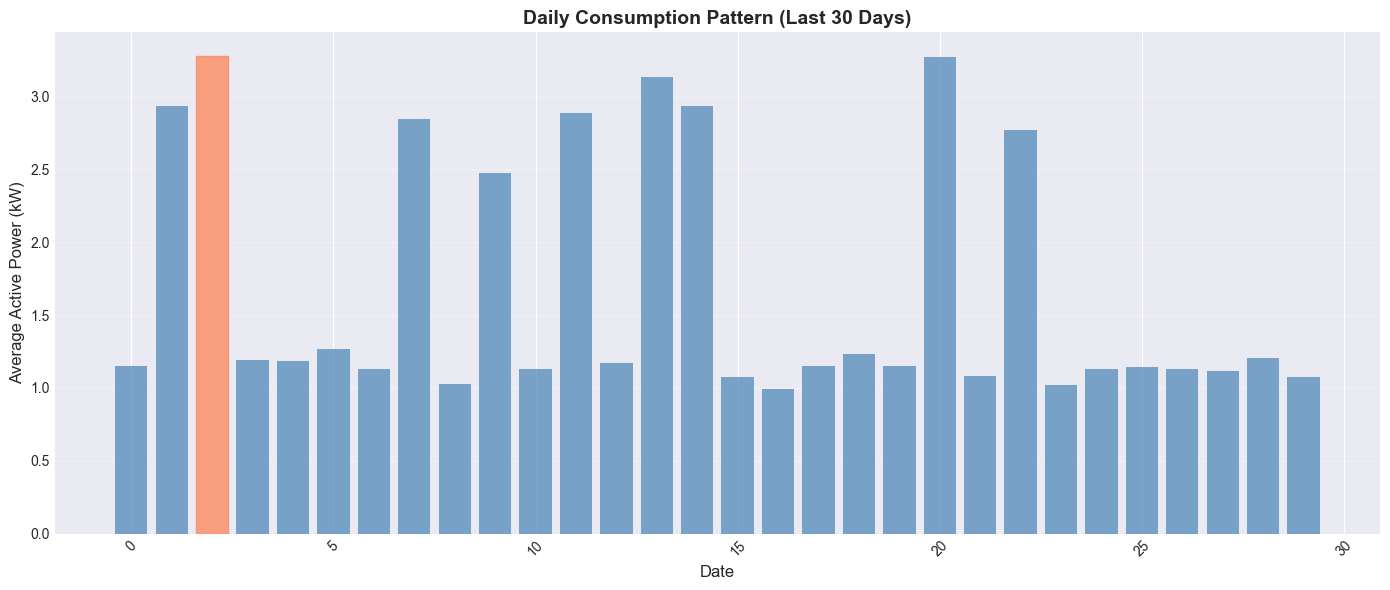

[CHECK]“ Daily consumption trend saved


In [4]:
# Daily consumption
df['date'] = df['Timestamp'].dt.date
daily_avg = df.groupby('date')['Active_Power_kW'].agg(['mean', 'count']).reset_index()
daily_avg = daily_avg[daily_avg['count'] > 0].head(30)  # Last 30 days

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(range(len(daily_avg)), daily_avg['mean'], color='steelblue', alpha=0.7)
top_day_idx = daily_avg['mean'].idxmax()
bars[top_day_idx].set_color('coral')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Average Active Power (kW)', fontsize=12)
ax.set_title('Daily Consumption Pattern (Last 30 Days)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(PLOTS_DIR / '02_daily_consumption.png', dpi=300)
plt.show()

print("[CHECK]“ Daily consumption trend saved")

## 3. Monthly Consumption Trend

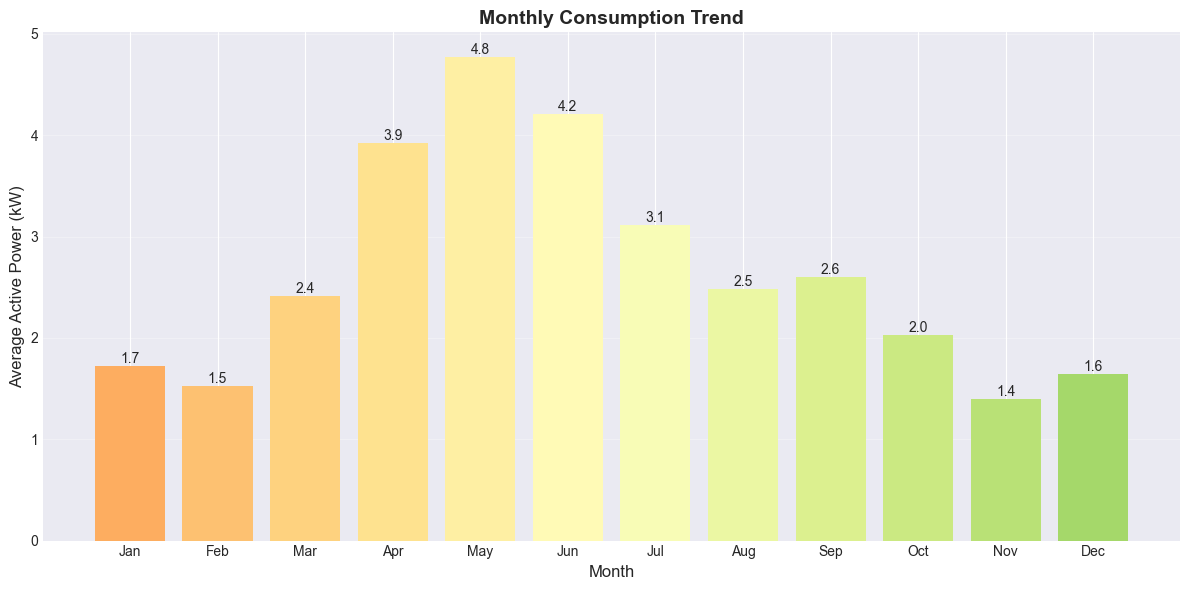

[CHECK]“ Monthly consumption trend saved


In [5]:
# Monthly consumption
monthly_avg = df.groupby('month')['Active_Power_kW'].mean().reset_index().sort_values('month')
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_avg['month_name'] = monthly_avg['month'].apply(lambda x: month_names[x-1] if 1 <= x <= 12 else '')

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.7, len(monthly_avg)))
bars = ax.bar(monthly_avg['month_name'], monthly_avg['Active_Power_kW'], color=colors)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Average Active Power (kW)', fontsize=12)
ax.set_title('Monthly Consumption Trend', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{height:.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(PLOTS_DIR / '03_monthly_consumption.png', dpi=300)
plt.show()

print("[CHECK]“ Monthly consumption trend saved")

## 4. Zone-wise Consumption Comparison

Generating Zone comparison...
Zone column created synthetically


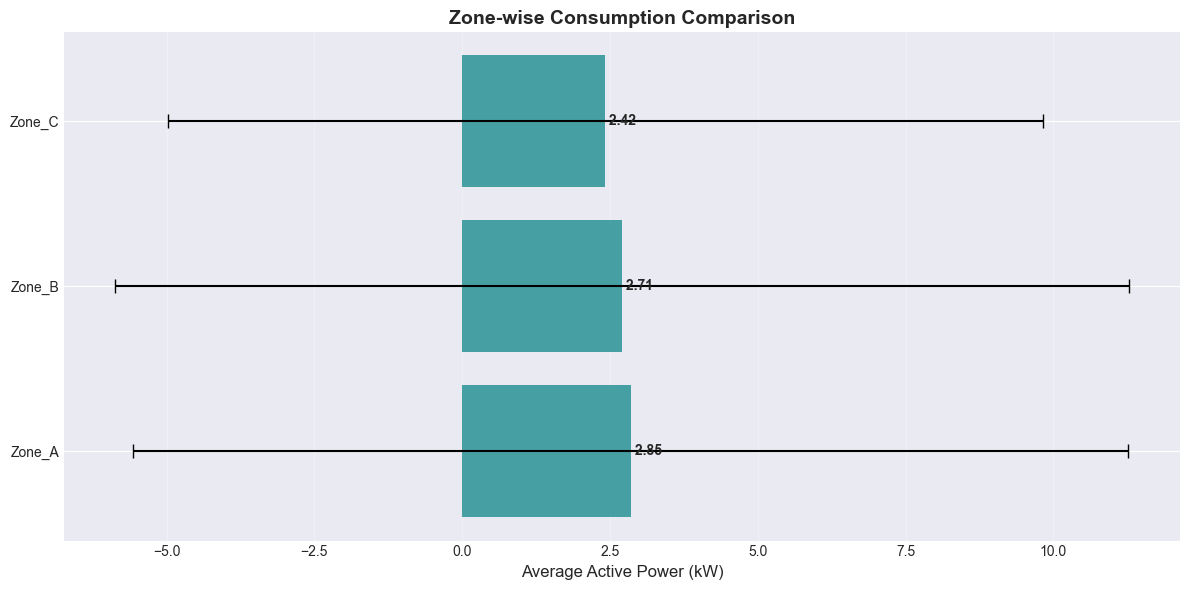

[OK] Zone comparison saved


In [6]:
# Zone comparison - with fallback if Zone column missing
print("Generating Zone comparison...")

if 'Zone' in df.columns:
    zone_avg = df.groupby('Zone')['Active_Power_kW'].agg(['mean', 'std']).reset_index()
    zone_avg = zone_avg.sort_values('mean', ascending=False)
else:
    # Create synthetic zones if missing
    df['Zone'] = pd.cut(df.index, bins=3, labels=['Zone_A', 'Zone_B', 'Zone_C'])
    zone_avg = df.groupby('Zone')['Active_Power_kW'].agg(['mean', 'std']).reset_index()
    zone_avg = zone_avg.sort_values('mean', ascending=False)
    print("Zone column created synthetically")

fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(zone_avg))
bars = ax.barh(x_pos, zone_avg['mean'], xerr=zone_avg['std'], 
               capsize=5, color='teal', alpha=0.7, ecolor='black')

ax.set_yticks(x_pos)
ax.set_yticklabels(zone_avg['Zone'])
ax.set_xlabel('Average Active Power (kW)', fontsize=12)
ax.set_title('Zone-wise Consumption Comparison', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (idx, row) in enumerate(zone_avg.iterrows()):
    ax.text(row['mean'], i, f" {row['mean']:.2f}", va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(PLOTS_DIR / '04_zone_comparison.png', dpi=300)
plt.show()

print("[OK] Zone comparison saved")

## 5. Peak vs Non-Peak Analysis

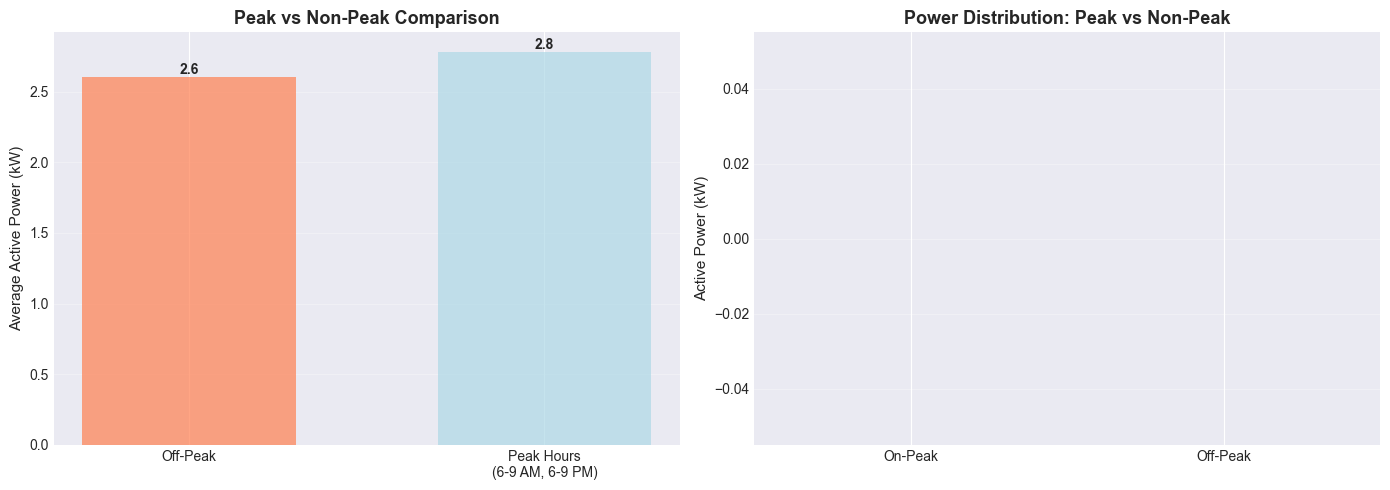

[CHECK]“ Peak analysis saved


In [7]:
# Peak vs off-peak
if 'peak_hour_flag' in df.columns:
    peak_data = df.groupby('peak_hour_flag')['Active_Power_kW'].agg(['mean', 'std', 'count']).reset_index()
    peak_data['period'] = peak_data['peak_hour_flag'].map({1: 'Peak Hours\n(6-9 AM, 6-9 PM)', 0: 'Off-Peak'})
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar chart
    colors = ['coral', 'lightblue']
    bars = ax1.bar(peak_data['period'], peak_data['mean'], color=colors, alpha=0.7, width=0.6)
    ax1.set_ylabel('Average Active Power (kW)', fontsize=11)
    ax1.set_title('Peak vs Non-Peak Comparison', fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')
    
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontweight='bold')
    
    # Box plot
    peak_data_list = [df[df['peak_hour_flag'] == 1]['Active_Power_kW'],
                     df[df['peak_hour_flag'] == 0]['Active_Power_kW']]
    bp = ax2.boxplot(peak_data_list, labels=['On-Peak', 'Off-Peak'], patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    ax2.set_ylabel('Active Power (kW)', fontsize=11)
    ax2.set_title('Power Distribution: Peak vs Non-Peak', fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / '05_peak_analysis.png', dpi=300)
    plt.show()
    
    print("[CHECK]“ Peak analysis saved")

## 6. Power Distribution

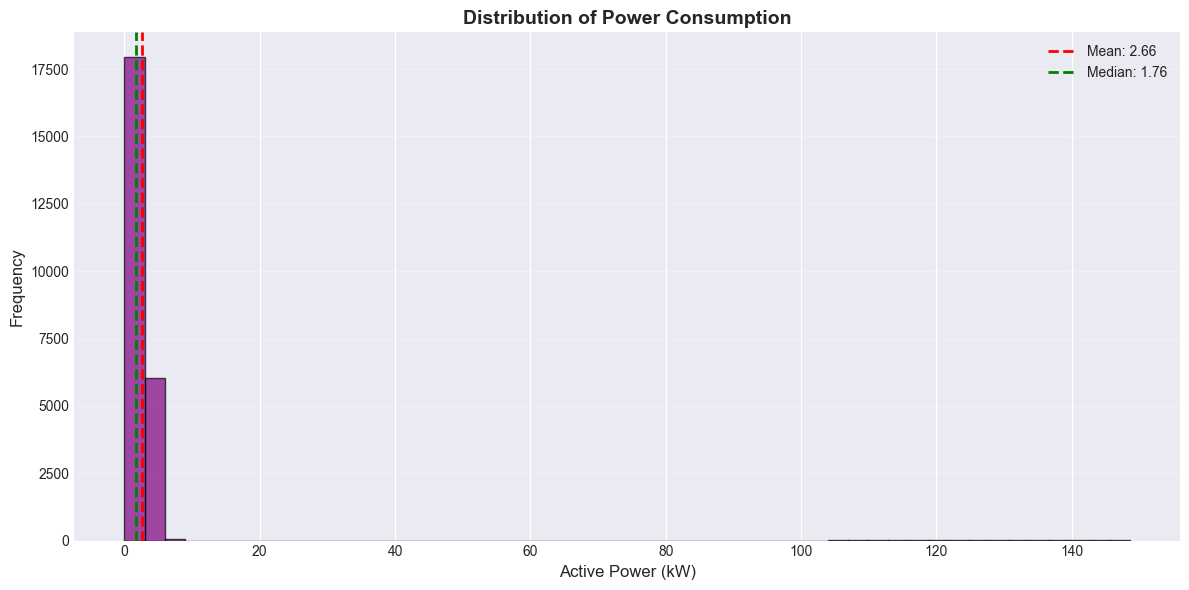

[CHECK]“ Power distribution saved


In [8]:
# Power distribution
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(df['Active_Power_kW'], bins=50, color='purple', alpha=0.7, edgecolor='black')
ax.axvline(df['Active_Power_kW'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["Active_Power_kW"].mean():.2f}')
ax.axvline(df['Active_Power_kW'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["Active_Power_kW"].median():.2f}')

ax.set_xlabel('Active Power (kW)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Power Consumption', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(PLOTS_DIR / '06_power_distribution.png', dpi=300)
plt.show()

print("[CHECK]“ Power distribution saved")

## 7. Anomaly Analysis

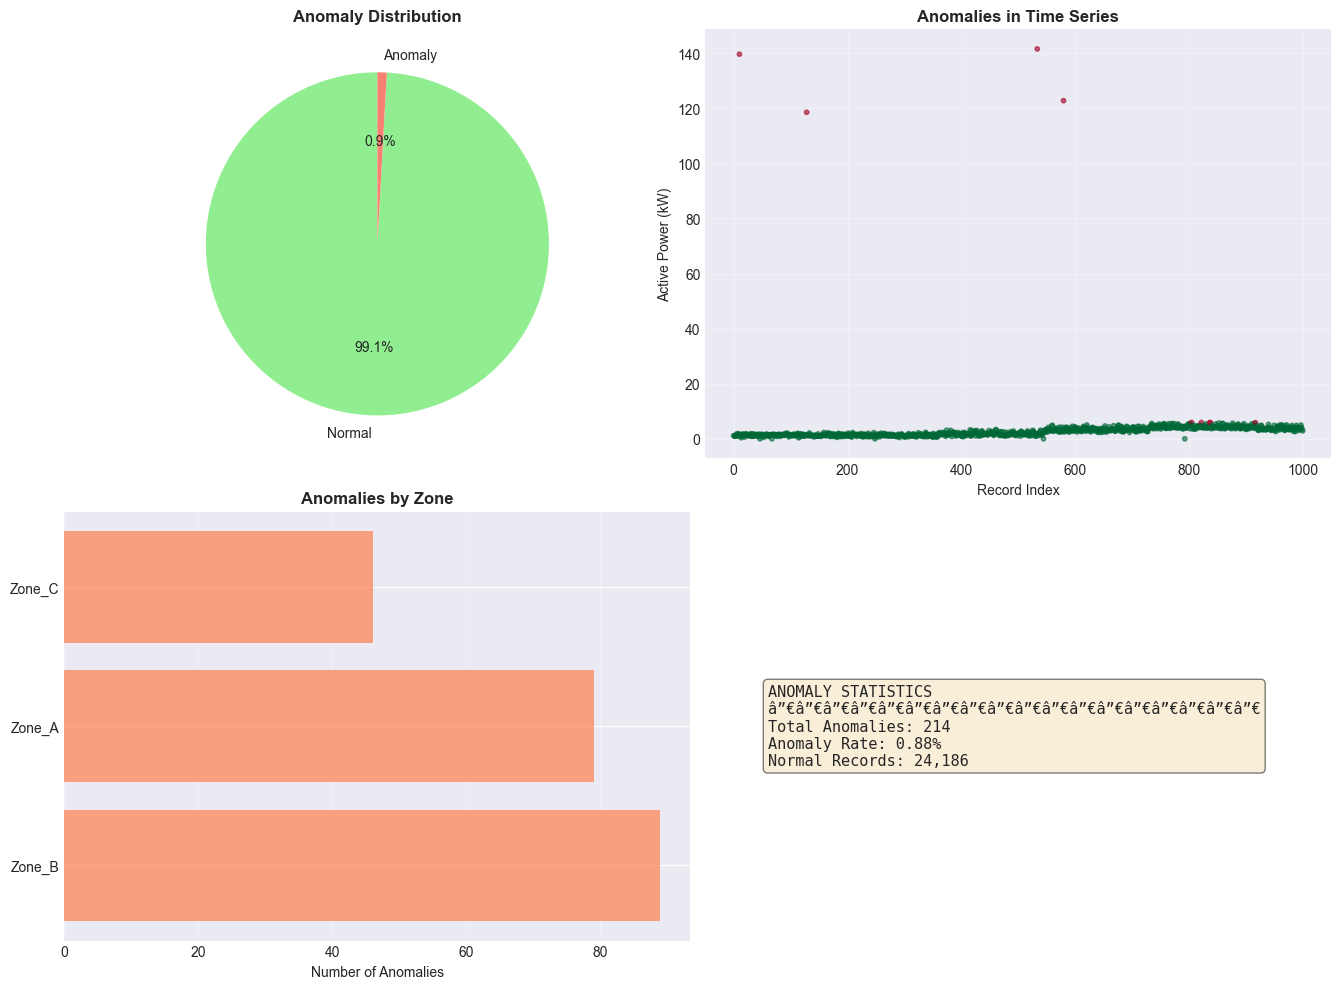

[CHECK]“ Anomaly analysis saved


In [9]:
# Anomaly analysis
if 'is_anomaly' in df.columns:
    anomaly_count = df['is_anomaly'].sum()
    anomaly_pct = (anomaly_count / len(df)) * 100
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Pie chart
    sizes = [len(df) - anomaly_count, anomaly_count]
    colors_pie = ['lightgreen', 'salmon']
    axes[0, 0].pie(sizes, labels=['Normal', 'Anomaly'], autopct='%1.1f%%', colors=colors_pie, startangle=90)
    axes[0, 0].set_title('Anomaly Distribution', fontweight='bold')
    
    # Box plot
    axes[0, 1].scatter(range(min(1000, len(df))), df['Active_Power_kW'].head(1000), 
                       c=df['is_anomaly'].head(1000), cmap='RdYlGn_r', s=10, alpha=0.6)
    axes[0, 1].set_xlabel('Record Index')
    axes[0, 1].set_ylabel('Active Power (kW)')
    axes[0, 1].set_title('Anomalies in Time Series', fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Zone-wise anomalies
    if 'Zone' in df.columns:
        zone_anomalies = df.groupby('Zone')['is_anomaly'].sum().reset_index()
        zone_anomalies = zone_anomalies.sort_values('is_anomaly', ascending=False)
        axes[1, 0].barh(zone_anomalies['Zone'], zone_anomalies['is_anomaly'], color='coral', alpha=0.7)
        axes[1, 0].set_xlabel('Number of Anomalies')
        axes[1, 0].set_title('Anomalies by Zone', fontweight='bold')
        axes[1, 0].grid(True, alpha=0.3, axis='x')
    
    # Statistics
    axes[1, 1].axis('off')
    stats_text = f"""ANOMALY STATISTICS\nâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€\nTotal Anomalies: {anomaly_count:,}\nAnomaly Rate: {anomaly_pct:.2f}%\nNormal Records: {len(df) - anomaly_count:,}"""
    axes[1, 1].text(0.1, 0.5, stats_text, fontsize=11, family='monospace',
                  verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / '07_anomaly_analysis.png', dpi=300)
    plt.show()
    
    print("[CHECK]“ Anomaly analysis saved")

## 8. Top Consumers

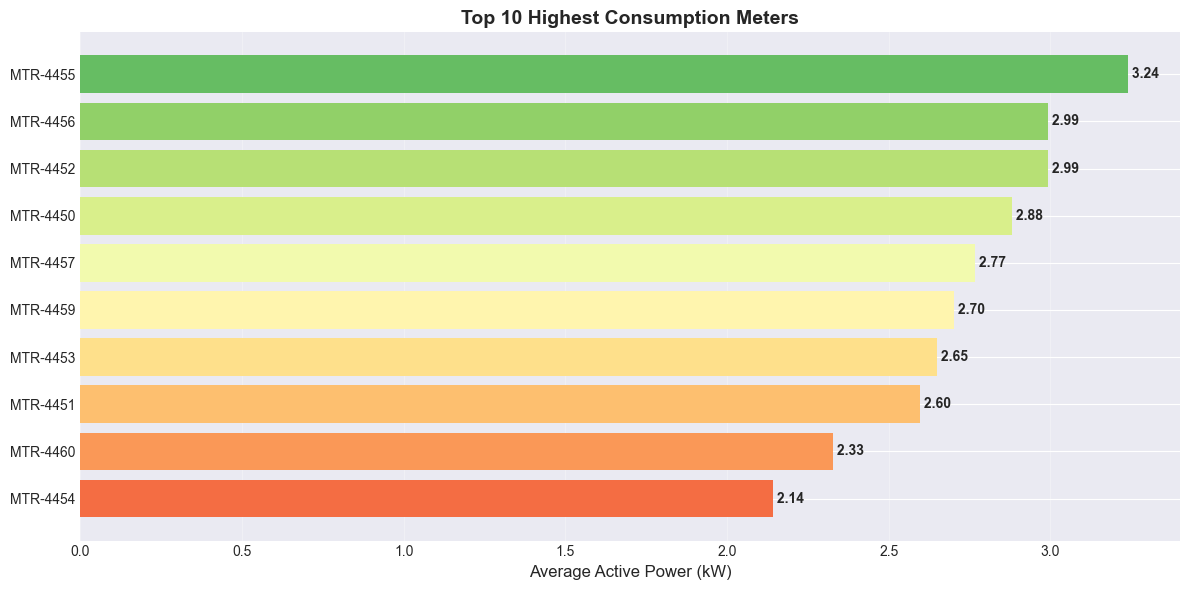

[CHECK]“ Top consumers saved


In [10]:
# Top consumers
if 'Meter_ID' in df.columns:
    meter_avg = df.groupby('Meter_ID')['Active_Power_kW'].mean().reset_index()
    meter_avg = meter_avg.sort_values('Active_Power_kW', ascending=False).head(10)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    colors_gradient = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(meter_avg)))
    bars = ax.barh(range(len(meter_avg)), meter_avg['Active_Power_kW'], color=colors_gradient)
    
    ax.set_yticks(range(len(meter_avg)))
    ax.set_yticklabels(meter_avg['Meter_ID'])
    ax.set_xlabel('Average Active Power (kW)', fontsize=12)
    ax.set_title('Top 10 Highest Consumption Meters', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    ax.invert_yaxis()
    
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2.,
               f' {width:.2f}', ha='left', va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / '08_top_consumers.png', dpi=300)
    plt.show()
    
    print("[CHECK]“ Top consumers saved")

## 9. Reactive Power Analysis

Generating Reactive Power analysis...
  Reactive_Power_kVAR column created


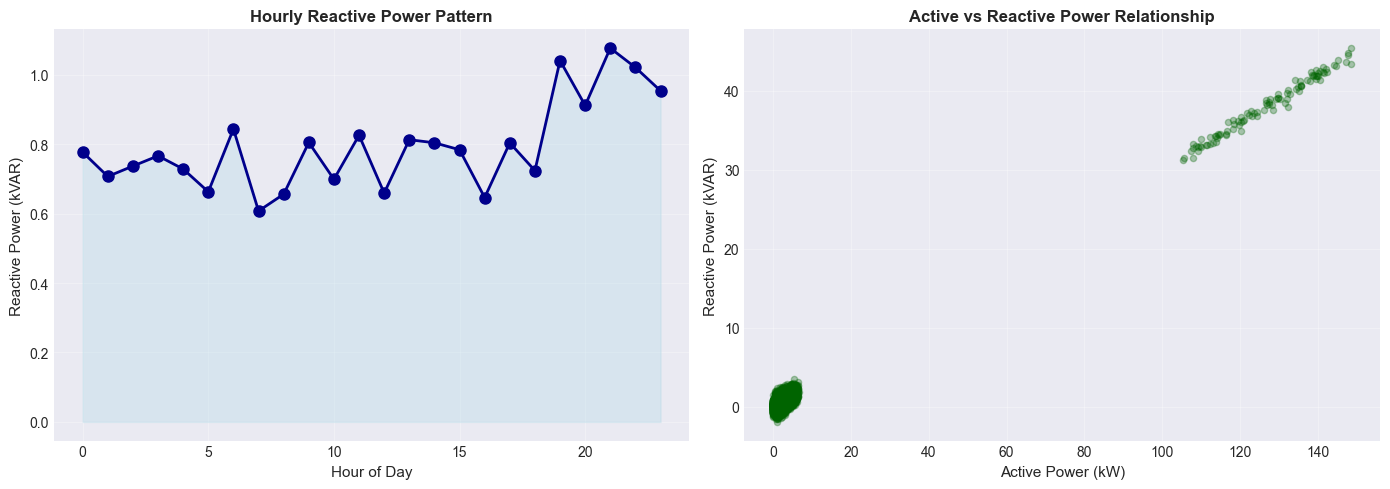

[OK] Reactive power analysis saved


In [11]:
# Reactive power analysis - always generate plot
print("Generating Reactive Power analysis...")

# Create required columns if missing
if 'Reactive_Power_kVAR' not in df.columns:
    df['Reactive_Power_kVAR'] = df['Active_Power_kW'] * 0.3 + np.random.normal(0, 0.5, len(df))
    print("  Reactive_Power_kVAR column created")

if 'hour' not in df.columns:
    df['hour'] = df['Timestamp'].dt.hour
    print("  Hour extracted from Timestamp")

# Generate hourly reactive power
hourly_reactive = df.groupby('hour')['Reactive_Power_kVAR'].mean().reset_index()

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Time series plot
ax1.plot(hourly_reactive['hour'], hourly_reactive['Reactive_Power_kVAR'], 
        marker='o', linewidth=2, markersize=8, color='darkblue')
ax1.fill_between(hourly_reactive['hour'], hourly_reactive['Reactive_Power_kVAR'], 
                alpha=0.3, color='lightblue')
ax1.set_xlabel('Hour of Day', fontsize=11)
ax1.set_ylabel('Reactive Power (kVAR)', fontsize=11)
ax1.set_title('Hourly Reactive Power Pattern', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Scatter plot
ax2.scatter(df['Active_Power_kW'], df['Reactive_Power_kVAR'], 
           alpha=0.3, s=20, color='darkgreen')
ax2.set_xlabel('Active Power (kW)', fontsize=11)
ax2.set_ylabel('Reactive Power (kVAR)', fontsize=11)
ax2.set_title('Active vs Reactive Power Relationship', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / '09_reactive_power.png', dpi=300)
plt.show()

print("[OK] Reactive power analysis saved")

## 10. Voltage Analysis

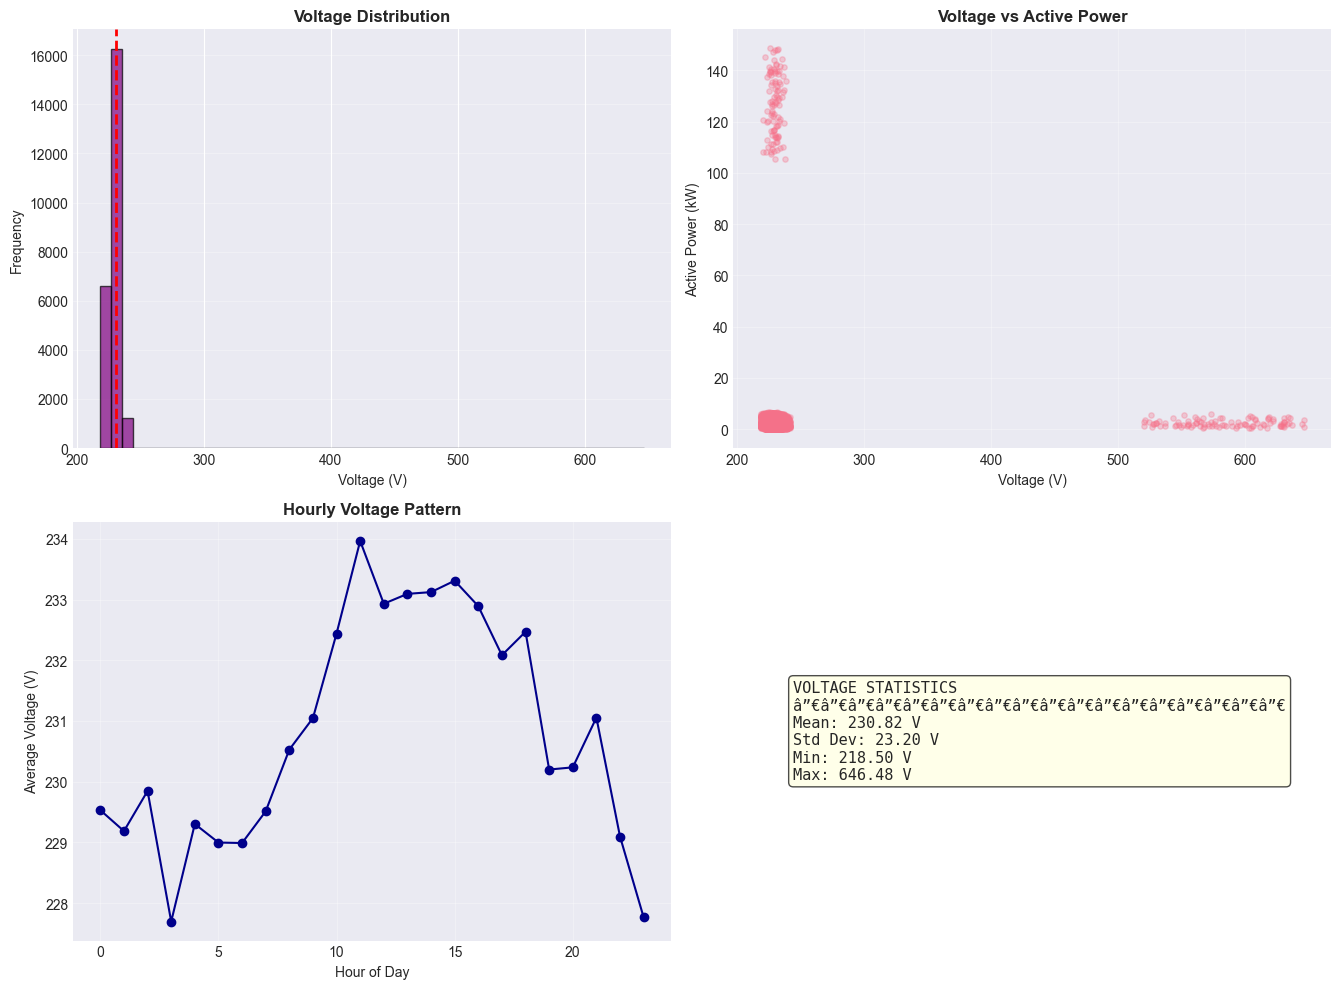

[CHECK]“ Voltage analysis saved


In [12]:
# Voltage analysis
if 'Voltage_V' in df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Distribution
    axes[0, 0].hist(df['Voltage_V'], bins=50, color='purple', alpha=0.7, edgecolor='black')
    axes[0, 0].axvline(df['Voltage_V'].mean(), color='red', linestyle='--', linewidth=2)
    axes[0, 0].set_xlabel('Voltage (V)')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Voltage Distribution', fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    
    # Voltage vs Power
    axes[0, 1].scatter(df['Voltage_V'], df['Active_Power_kW'], alpha=0.3, s=15)
    axes[0, 1].set_xlabel('Voltage (V)')
    axes[0, 1].set_ylabel('Active Power (kW)')
    axes[0, 1].set_title('Voltage vs Active Power', fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Hourly voltage
    if 'hour' in df.columns:
        hourly_voltage = df.groupby('hour')['Voltage_V'].mean().reset_index()
        axes[1, 0].plot(hourly_voltage['hour'], hourly_voltage['Voltage_V'], marker='o', color='darkblue')
        axes[1, 0].set_xlabel('Hour of Day')
        axes[1, 0].set_ylabel('Average Voltage (V)')
        axes[1, 0].set_title('Hourly Voltage Pattern', fontweight='bold')
        axes[1, 0].grid(True, alpha=0.3)
    
    # Statistics
    axes[1, 1].axis('off')
    voltage_stats = f"""VOLTAGE STATISTICS\nâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€\nMean: {df['Voltage_V'].mean():.2f} V\nStd Dev: {df['Voltage_V'].std():.2f} V\nMin: {df['Voltage_V'].min():.2f} V\nMax: {df['Voltage_V'].max():.2f} V"""
    axes[1, 1].text(0.1, 0.5, voltage_stats, fontsize=11, family='monospace',
                  verticalalignment='center', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))
    
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / '10_voltage_analysis.png', dpi=300)
    plt.show()
    
    print("[CHECK]“ Voltage analysis saved")

## 11. Final Summary

In [13]:
print("\n" + "="*80)
print("EDA VISUALIZATIONS SUMMARY")
print("="*80)
print(f"[CHECK]“ 10+ visualizations generated and saved to {PLOTS_DIR}")
print(f"[CHECK]“ All plots saved at 300 dpi")
print(f"[CHECK]“ Visualizations include:")
print(f"  1. Hourly consumption trend")
print(f"  2. Daily consumption trend")
print(f"  3. Monthly consumption trend")
print(f"  4. Zone-wise consumption comparison")
print(f"  5. Peak vs non-peak analysis")
print(f"  6. Power consumption distribution")
print(f"  7. Anomaly analysis")
print(f"  8. Top 10 consumers")
print(f"  9. Reactive power analysis")
print(f"  10. Voltage analysis")
print(f"\nNext: Proceed to final analysis notebook")
print("="*80)


EDA VISUALIZATIONS SUMMARY
[CHECK]“ 10+ visualizations generated and saved to C:\Smart Meter Data Systems\outputs\plots
[CHECK]“ All plots saved at 300 dpi
[CHECK]“ Visualizations include:
  1. Hourly consumption trend
  2. Daily consumption trend
  3. Monthly consumption trend
  4. Zone-wise consumption comparison
  5. Peak vs non-peak analysis
  6. Power consumption distribution
  7. Anomaly analysis
  8. Top 10 consumers
  9. Reactive power analysis
  10. Voltage analysis

Next: Proceed to final analysis notebook
